# autogluon leave out method

In [1]:
import pandas as pd
import numpy as np
import nucml.datasets as nuc_data
from autogluon.tabular import TabularPredictor
import matplotlib.pyplot as plt

# Increase logging for better visibility
import logging
logging.getLogger("autogluon").setLevel(logging.INFO)

/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load EXFOR with AME physics
exfor_df = nuc_data.load_exfor()
exfor_df['MT'] = pd.to_numeric(exfor_df['MT'], errors='coerce')
actinides = exfor_df[(exfor_df['MT'] == 18) & (exfor_df['Z'] >= 89)].copy()

# Load RIPL/ENSDF
ensdf_ml, _, _, _, _, _, _ = nuc_data.load_ensdf_ml(cutoff=False, append_ame=True, basic=1, num=True)
ripl_grouped = ensdf_ml.groupby(['Z', 'A']).mean().reset_index()

# Merge
master_df = pd.merge(actinides, ripl_grouped, on=['Z', 'A'], how='left', suffixes=('_exfor', '_ripl'))

# Apply Fast Regime Filter (> 200 keV)
energy_col = 'Energy_exfor' if 'Energy_exfor' in master_df.columns else 'Energy'
df_fast = master_df[master_df[energy_col] >= 200000].copy()

# Feature Selection
features = [energy_col, 'Z', 'A', 'Binding_Energy_exfor', 'S(n)_exfor', 'Level_Number']
target = 'Data'
df_ml = df_fast[features + [target, 'Isotope']].dropna().copy()

# Log Transform Target
df_ml['label'] = np.log10(df_ml[target] + 1e-10)



# ==========================================
# NEW CELL: FEATURE SCALING & TRANSFORMATION
# ==========================================
from sklearn.preprocessing import StandardScaler

print(">>> Pre-processing: Transforming Energy and Scaling Physics Features...")

# 1. Log-transform Incident Energy 
# This helps the model correlate energy scales with cross-section orders of magnitude
df_ml['Energy_Log'] = np.log10(df_ml[energy_col])

# 2. Select physics features that need scaling 
# We don't scale 'Energy_Log' yet to keep it as a primary reference, 
# but we scale Z, A, Binding Energy, and Sn so they share the same numerical range.
features_to_scale = ['Z', 'A', 'Binding_Energy_exfor', 'S(n)_exfor', 'Level_Number']

scaler = StandardScaler()
df_ml[features_to_scale] = scaler.fit_transform(df_ml[features_to_scale])

# 3. Update the Feature List for training
# We replace the raw energy with the Log Energy
features = ['Energy_Log', 'Z', 'A', 'Binding_Energy_exfor', 'S(n)_exfor', 'Level_Number']

print(">>> Scaling complete. Physics features now have Mean=0 and Std=1.")



INFO:root: MODE: neutrons
INFO:root: LOW ENERGY: False
INFO:root: LOG: False
INFO:root: BASIC: -1
INFO:root:Reading data from /Users/glsw/main/NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv
INFO:root:Data read into dataframe with shape: (4395295, 104)
INFO:root:Finished. Resulting dataset has shape (4395295, 104)
INFO:root:AME: Reading and loading Atomic Mass Evaluation files from: 
 /Users/glsw/main/NucMLClone2/AME/CSV_Files/AME_all_merged_no_NaN.csv
INFO:root:Dropping unnecessary features and one-hot encoding categorical columns...
INFO:root:Splitting dataset into training and testing...
INFO:root:Normalizing dataset...
INFO:root:Fitting new scaler.
INFO:root:Finished. Resulting dataset has shape (72667, 12), Training and Testing dataset shapes are (50866, 11) and (21801, 11) respesctively.


>>> Pre-processing: Transforming Energy and Scaling Physics Features...
>>> Scaling complete. Physics features now have Mean=0 and Std=1.


In [3]:
# Updated Splitting Logic
target_iso = '241Am'
# Ensure we only pass the transformed features and the label to the trainer
train_data = df_ml[df_ml['Isotope'] != target_iso][features + ['label']]
test_data = df_ml[df_ml['Isotope'] == target_iso][features + ['label']]

print(f"Training on {len(train_data)} points using scaled features. Predicting {target_iso}.")

Training on 33682 points using scaled features. Predicting 241Am.


In [4]:
# AutoGluon will automatically try XGBoost, WeightedEnsembles, and more
predictor_m1 = TabularPredictor(label='label', eval_metric='root_mean_squared_error').fit(
    train_data, 
    presets='best_quality', # Maximizes accuracy by using stacking/ensembling
    time_limit=600          # 10 minute limit for training
)

No path specified. Models will be saved in: "AutogluonModels/ag-20260127_125330"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.2.0: Tue Nov 18 21:09:40 PST 2025; root:xnu-12377.61.12~1/RELEASE_ARM64_T6000
CPU Count:          8
Memory Avail:       4.05 GB / 16.00 GB (25.3%)
Disk Space Avail:   286.69 GB / 460.43 GB (62.3%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking a

(_ray_fit pid=56759) [1000]	valid_set's rmse: 0.119523
(_ray_fit pid=56759) [4000]	valid_set's rmse: 0.101848 [repeated 24x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(_ray_fit pid=56759) [8000]	valid_set's rmse: 0.0990534 [repeated 31x across cluster]


(_dystack pid=56742) 	-0.1822	 = Validation score   (-root_mean_squared_error)
(_dystack pid=56742) 	17.33s	 = Training   runtime
(_dystack pid=56742) 	46.23s	 = Validation runtime
(_dystack pid=56742) Fitting model: LightGBM_BAG_L1 ... Training model for up to 69.57s of the 118.85s of remaining time.
(_dystack pid=56742) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=1, gpus=0, memory=0.38%)


(_ray_fit pid=56828) [1000]	valid_set's rmse: 0.229407 [repeated 18x across cluster]


(_dystack pid=56742) 	-0.183	 = Validation score   (-root_mean_squared_error)
(_dystack pid=56742) 	6.09s	 = Training   runtime
(_dystack pid=56742) 	3.99s	 = Validation runtime
(_dystack pid=56742) Fitting model: RandomForestMSE_BAG_L1 ... Training model for up to 59.01s of the 108.29s of remaining time.
(_dystack pid=56742) 	-0.2102	 = Validation score   (-root_mean_squared_error)
(_dystack pid=56742) 	2.21s	 = Training   runtime
(_dystack pid=56742) 	0.89s	 = Validation runtime
(_dystack pid=56742) Fitting model: CatBoost_BAG_L1 ... Training model for up to 55.56s of the 104.84s of remaining time.
(_dystack pid=56742) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=1, gpus=0, memory=9.95%)
(_dystack pid=56742) 	-0.182	 = Validation score   (-root_mean_squared_error)
(_dystack pid=56742) 	44.47s	 = Training   runtime
(_dystack pid=56742) 	0.07s	 = Validation runtime
(_dystack pid=56742) Fitting model: ExtraTreesMSE_BAG_L1 ..

(_ray_fit pid=57026) [1000]	valid_set's rmse: 0.312411 [repeated 11x across cluster]
(_ray_fit pid=57026) [5000]	valid_set's rmse: 0.308454 [repeated 12x across cluster]
(_ray_fit pid=57026) [9000]	valid_set's rmse: 0.306835 [repeated 4x across cluster]


(_dystack pid=56742) 	-0.1758	 = Validation score   (-root_mean_squared_error)
(_dystack pid=56742) 	14.87s	 = Training   runtime
(_dystack pid=56742) 	6.72s	 = Validation runtime
(_dystack pid=56742) Fitting model: LightGBM_BAG_L2 ... Training model for up to 24.54s of the 24.52s of remaining time.
(_ray_fit pid=56989) 	Ran out of time, stopping training early. (Stopping on epoch 11) [repeated 5x across cluster]
(_dystack pid=56742) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=1, gpus=0, memory=0.45%)
(_dystack pid=56742) 	-0.1803	 = Validation score   (-root_mean_squared_error)
(_dystack pid=56742) 	0.81s	 = Training   runtime
(_dystack pid=56742) 	0.15s	 = Validation runtime
(_dystack pid=56742) Fitting model: RandomForestMSE_BAG_L2 ... Training model for up to 21.99s of the 21.96s of remaining time.
(_dystack pid=56742) 	-0.1884	 = Validation score   (-root_mean_squared_error)
(_dystack pid=56742) 	11.55s	 = Training   

In [5]:
# Predict and Inverse Log
y_pred_log = predictor_m1.predict(test_data)
y_pred_real = 10**y_pred_log

# Sort and Plot
sort_idx = np.argsort(test_data[energy_col].values)
plt.figure(figsize=(10, 6))
plt.scatter(test_data[energy_col], 10**test_data['label'], color='black', alpha=0.3, label='EXFOR')
plt.plot(test_data[energy_col].values[sort_idx], y_pred_real.values[sort_idx], color='red', lw=3, label='AutoGluon Method 1')

plt.xscale('log'); plt.yscale('log')
plt.title(f"Method 1: {target_iso} Prediction (Unseen Isotope)")
plt.legend(); plt.show()

KeyError: 'Energy_exfor'

>>> Step 5: Visualizing AutoGluon Results with Multiple Benchmarks...


INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/endfb8.0/tables/xs/n-Am241-MT018.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
INFO:root:EVALUATION: Finished. ENDF data contains 16294 datapoints.
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/tendl.2019/tables/xs/n-Am241-MT018.tendl.2019
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future ver

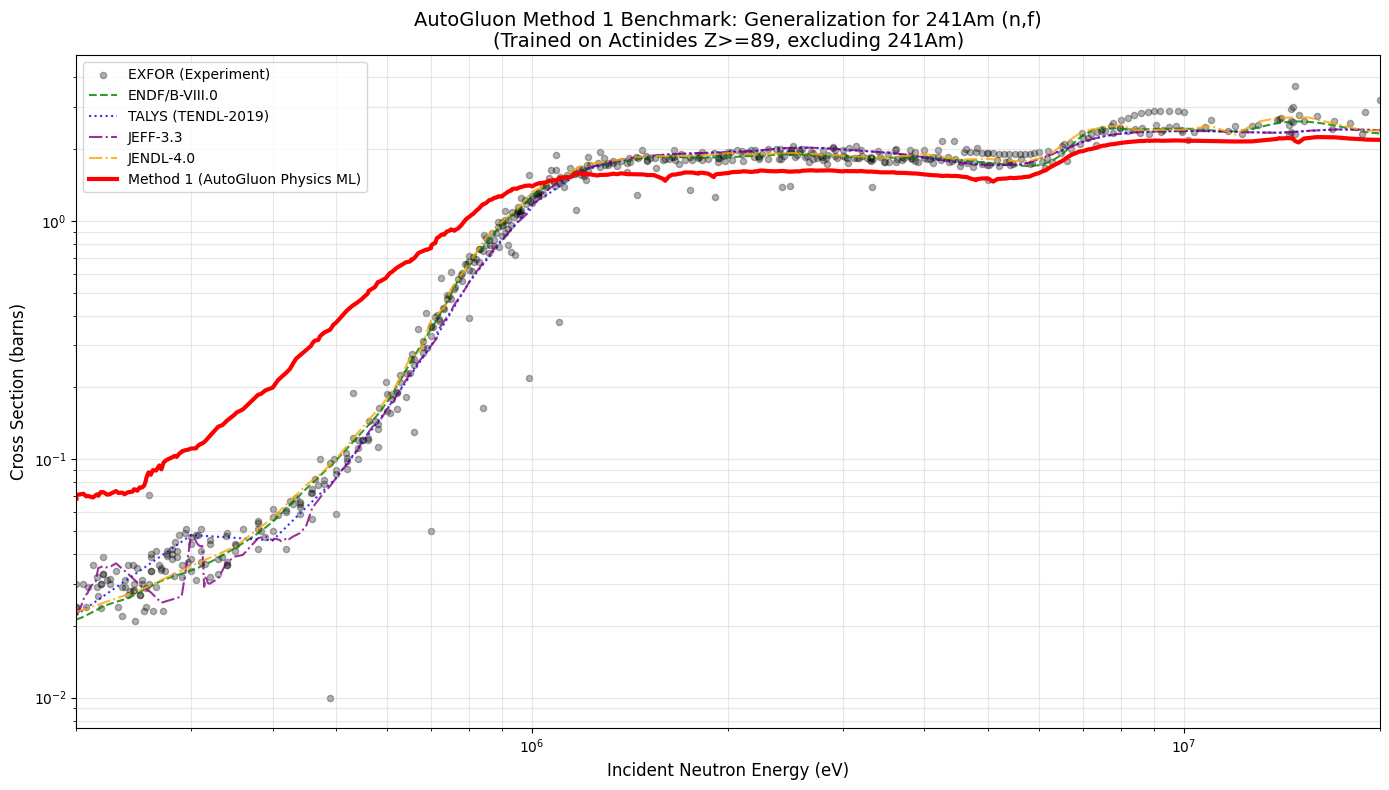

AutoGluon Method 1 Log-Space MAE: 0.2192


In [ ]:
# ==========================================
# 7. PREDICTION & VISUALIZATION (FINAL BENCHMARK)
# ==========================================
print(">>> Step 5: Visualizing AutoGluon Results with Multiple Benchmarks...")

# 1. Get AutoGluon Model Predictions
# predictor_m1 was trained on Log10 space; we inverse transform here
y_pred_log = predictor_m1.predict(test_data)
y_pred_real = 10**y_pred_log

# Sort ML data for a clean line plot
sort_idx = np.argsort(test_data[energy_col].values)
E_plot = test_data[energy_col].values[sort_idx]
y_pred_plot = y_pred_real.values[sort_idx]
y_actual_plot = (10**test_data['label'].values)[sort_idx]

# 2. Setup Plot
plt.figure(figsize=(14, 8))

# 3. Plot EXFOR (Experimental Data)
plt.scatter(E_plot, y_actual_plot, color='black', s=20, alpha=0.3, label='EXFOR (Experiment)')

# --- HELPER FUNCTION FOR LOADING EVALUATIONS ---
def load_and_fix(iso, mt, lib, color, style, label):
    try:
        # Load from the directory names found in your file system
        df = nuc_data.load_evaluation(iso, mt, library=lib)
        if not df.empty:
            # Correction for Log10 vs Linear units in NucML loaders
            e = 10**df['Energy'] if df['Energy'].max() < 100 else df['Energy']
            d = 10**df['Data'] if df['Data'].max() < 10 else df['Data']
            
            # Filter for the Fast Regime (>= 200 keV)
            mask = e >= 2e5
            plt.plot(e[mask], d[mask], color=color, linestyle=style, linewidth=1.5, label=label, alpha=0.8)
            return True
    except:
        return False
    return False

# 4. Plot Benchmarks using the library keys found in your directory
load_and_fix("am241", 18, "endfb8.0", "green", "--", "ENDF/B-VIII.0")
load_and_fix("am241", 18, "tendl.2019", "blue", ":", "TALYS (TENDL-2019)")
load_and_fix("am241", 18, "jeff3.3", "purple", "-.", "JEFF-3.3")
load_and_fix("am241", 18, "jendl4.0", "orange", "-.", "JENDL-4.0")

# 5. Plot Your AutoGluon ML Model (The Red Line)
plt.plot(E_plot, y_pred_plot, color='red', linewidth=3, label='Method 1 (AutoGluon Physics ML)')

# 6. Final Formatting
plt.xscale('log')
plt.yscale('log')
plt.xlim(2e5, 2e7) # Focus on Fast Regime (200 keV - 20 MeV)
plt.xlabel('Incident Neutron Energy (eV)', fontsize=12)
plt.ylabel('Cross Section (barns)', fontsize=12)
plt.title(f'AutoGluon Method 1 Benchmark: Generalization for {target_iso} (n,f)\n(Trained on Actinides Z>=89, excluding {target_iso})', fontsize=14)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()

plt.show()

# 7. Print Performance Metric
from sklearn.metrics import mean_absolute_error
mae_log = mean_absolute_error(test_data['label'], y_pred_log)
print(f"AutoGluon Method 1 Log-Space MAE: {mae_log:.4f}")

In [ ]:
# ==========================================
# LEADERBOARD: Model Ranking on Am-241 Test Data
# ==========================================
print(f">>> Generating Leaderboard for {target_iso} specifically...")

# 1. Generate the leaderboard using the test data
# Note: For Method 1 use 'test_data'. For Method 2 use 'test_subset'.
test_to_use = test_data if 'test_data' in locals() else test_subset

leaderboard = predictor_m1.leaderboard(test_to_use, silent=False) if 'predictor_m1' in locals() else predictor_res.leaderboard(test_to_use, silent=False)

# 2. Display the top performing models
print("\nTop Models Ranked by Performance on Am-241:")
print(leaderboard[['model', 'score_test', 'score_val', 'pred_time_test', 'stack_level']])

# 3. Highlight the best model
best_model_name = leaderboard.iloc[0]['model']
print(f"\n The best performing model for this isotope was: {best_model_name}")

>>> Generating Leaderboard for 241Am specifically...
                     model  score_test  score_val              eval_metric  pred_time_test  pred_time_val    fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0           XGBoost_BAG_L1   -0.133409  -0.188408  root_mean_squared_error        0.102272       0.168735    1.234540                 0.102272                0.168735           1.234540            1       True          7
1     CatBoost_r177_BAG_L1   -0.251754  -0.188912  root_mean_squared_error        0.077498       0.033045    7.685671                 0.077498                0.033045           7.685671            1       True         10
2          LightGBM_BAG_L1   -0.256177  -0.187269  root_mean_squared_error        0.345705       2.481430    6.341878                 0.345705                2.481430           6.341878            1       True          2
3        LightGBMXT_BAG_L1   -0.266077  -0.186597  root_mean_sq

Computing feature importance via permutation shuffling for 6 features using 573 rows with 5 shuffle sets...


>>> Calculating Feature Importance for 241Am...


	76.87s	= Expected runtime (15.37s per shuffle set)
	34.28s	= Actual runtime (Completed 5 of 5 shuffle sets)


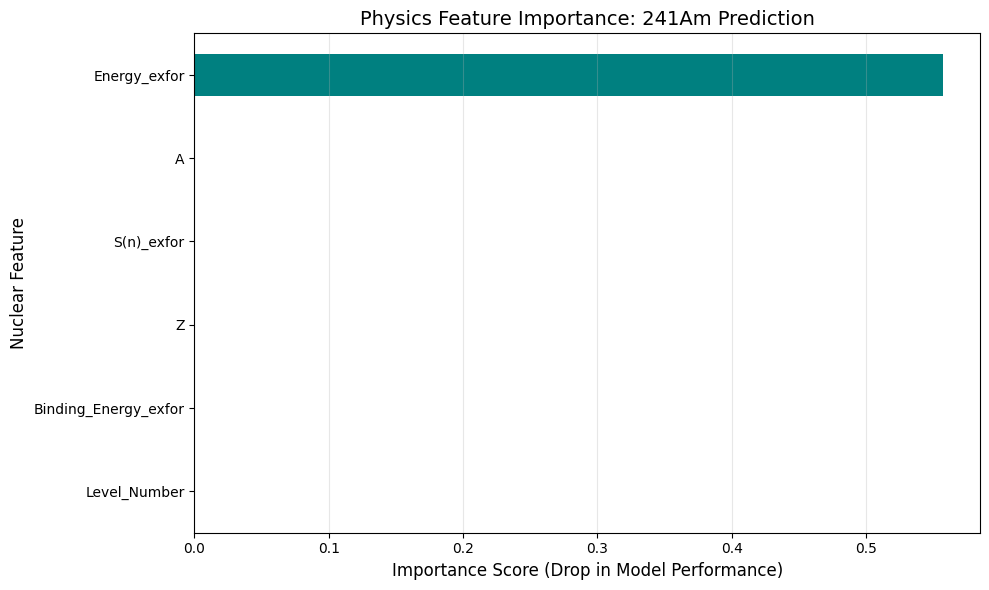

                        importance    stddev       p_value  n      p99_high  \
Energy_exfor          5.567957e-01  0.009427  9.856663e-09  5  5.762061e-01   
A                     5.929649e-10  0.000000  5.000000e-01  5  5.929649e-10   
S(n)_exfor            5.446446e-10  0.000000  5.000000e-01  5  5.446446e-10   
Z                     2.575773e-11  0.000000  5.000000e-01  5  2.575773e-11   
Binding_Energy_exfor -2.084447e-10  0.000000  5.000000e-01  5 -2.084447e-10   
Level_Number         -4.956371e-10  0.000000  5.000000e-01  5 -4.956371e-10   

                           p99_low  
Energy_exfor          5.373853e-01  
A                     5.929649e-10  
S(n)_exfor            5.446446e-10  
Z                     2.575773e-11  
Binding_Energy_exfor -2.084447e-10  
Level_Number         -4.956371e-10  


In [ ]:
# ==========================================
# 8. FEATURE IMPORTANCE (INTERPRETABLE AI)
# ==========================================
print(f">>> Calculating Feature Importance for {target_iso}...")

# Use the predictor from your current notebook (m1 or res)
current_predictor = predictor_m1 if 'predictor_m1' in locals() else predictor_res
# Use the corresponding test data
current_test = test_data if 'test_data' in locals() else test_subset

# Calculate Importance
importance = current_predictor.feature_importance(current_test)

# Plotting
plt.figure(figsize=(10, 6))
importance['importance'].sort_values().plot(kind='barh', color='teal')
plt.title(f'Physics Feature Importance: {target_iso} Prediction', fontsize=14)
plt.xlabel('Importance Score (Drop in Model Performance)', fontsize=12)
plt.ylabel('Nuclear Feature', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(importance)

In [1]:
import seaborn as sns

import nucml.exfor.data_utilities as exfor_utils
import nucml.evaluation.data_utilities as eval_utils
import nucml.datasets as nuc_data
import nucml.evaluation.plot as eval_plot

In [2]:
df = nuc_data.load_exfor()

INFO:root: MODE: neutrons
INFO:root: LOW ENERGY: False
INFO:root: LOG: False
INFO:root: BASIC: -1
INFO:root:Reading data from /Users/glsw/main/NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv
INFO:root:Data read into dataframe with shape: (4395295, 104)
INFO:root:Finished. Resulting dataset has shape (4395295, 104)


INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/endfb8.0/tables/xs/n-Am241-MT018.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
INFO:root:EVALUATION: Finished. ENDF data contains 16294 datapoints.
INFO:root:Extracting samples from dataframe.
INFO:root:EXFOR extracted DataFrame has shape: (9285, 104)


AttributeError: 'DataFrame' object has no attribute 'append'

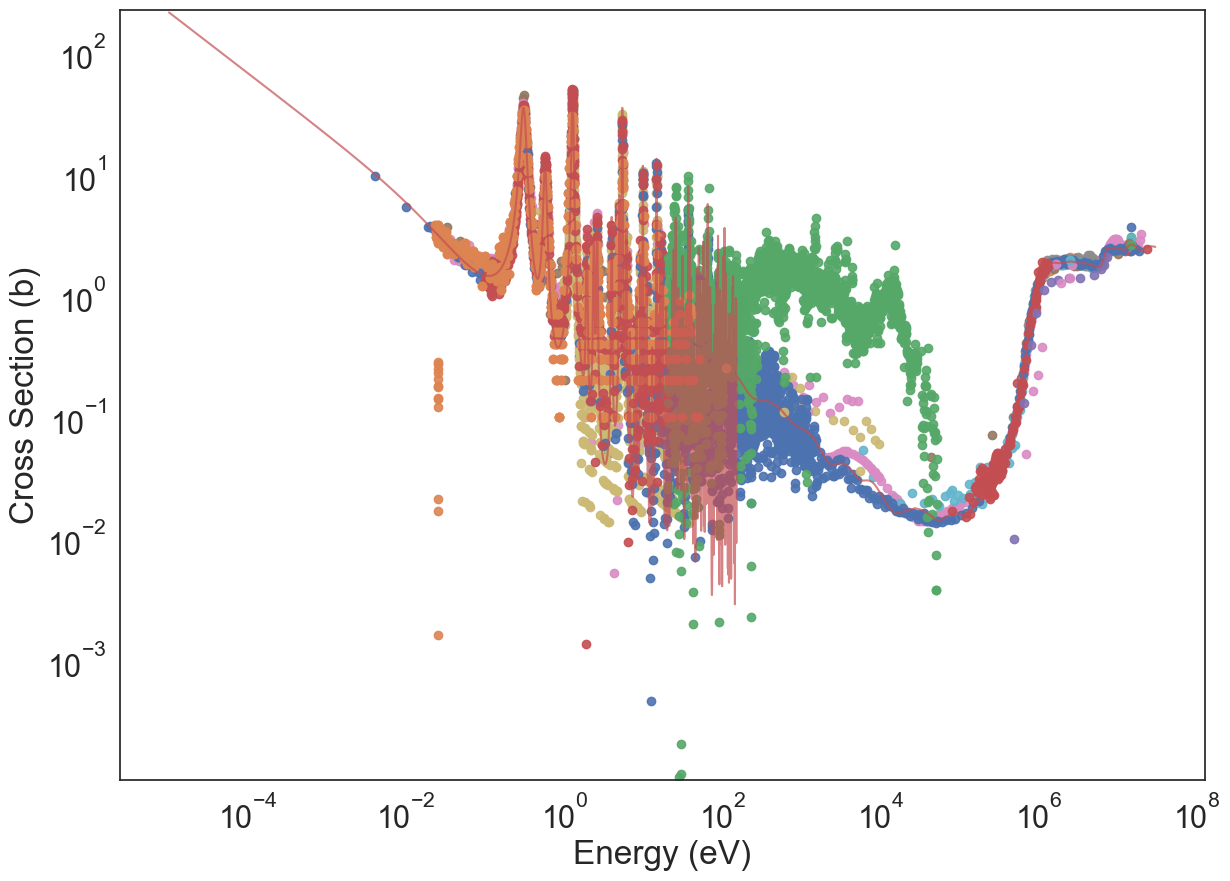

In [12]:
df.MT = df.MT.astype(int)
figure_dir = "./figs2pres/"

kwargs = {"nat_iso":"I", "one_hot":False, "alpha":0.7, "legend":False, "interpolate":False,
          "log_plot":True, "ref":True}

cl_exfor_endf = exfor_utils.plot_exfor_w_references(df, 95, 241, 18,
                                                    get_endf=True,
                                                    error=True,
                                                    save=True,
                                                    path=figure_dir,
                                                    **kwargs)

